In [41]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.model_selection import (
    cross_validate, StratifiedKFold, GridSearchCV,
    train_test_split, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
import joblib

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

---
## Task 1 — Unsupervised Exploration

In [42]:
# 1.1  Load dataset 
df_raw = sns.load_dataset('penguins')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [43]:
# 1.2  Data cleaning
print('Missing values per column:')
print(df_raw.isnull().sum())

df = df_raw.dropna().reset_index(drop=True)
print(f'\nAfter dropna: {df.shape}')

# Distribution of numeric features
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df[numeric_cols].describe()

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

After dropna: (333, 7)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


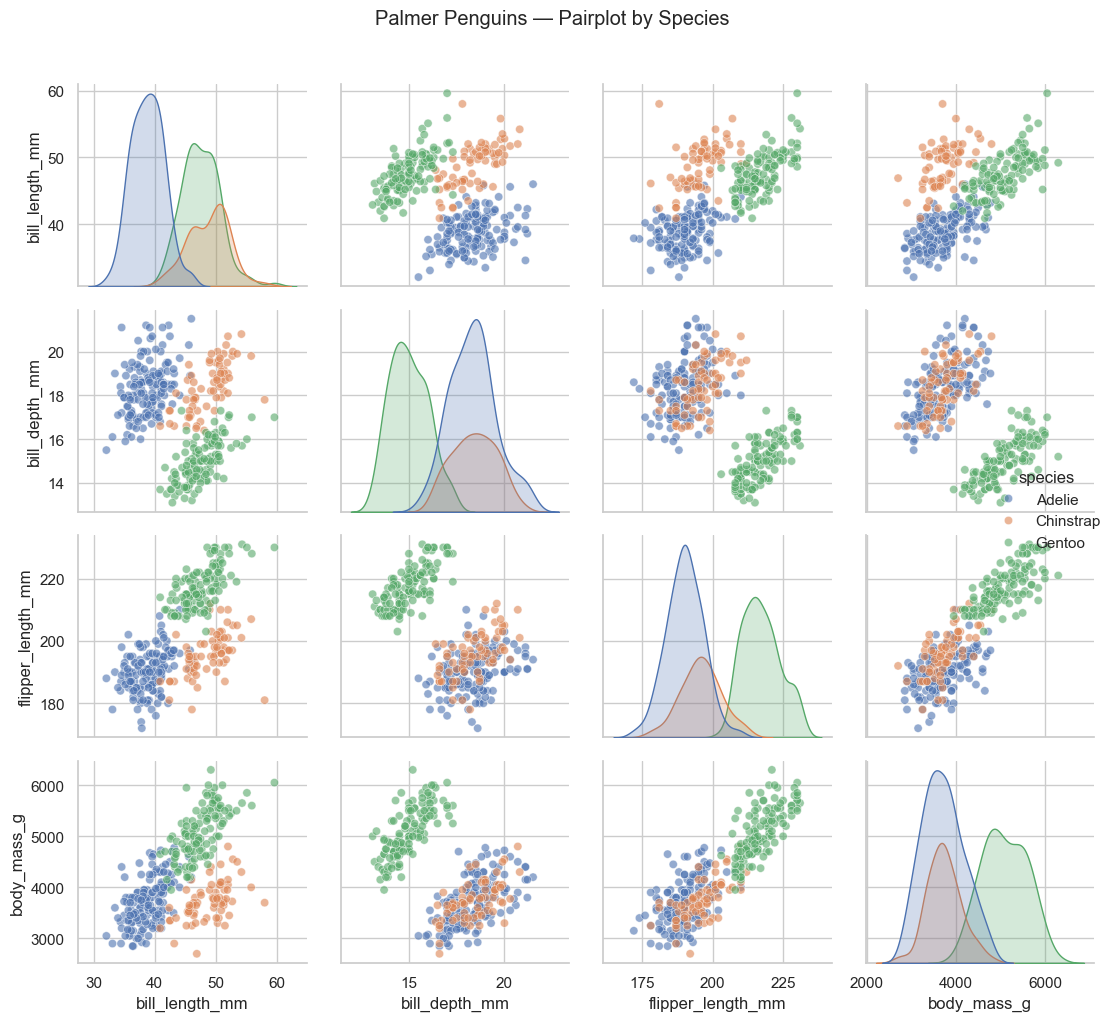

In [44]:
# Pairplot to examine distributions and detect anomalies
sns.pairplot(df, hue='species', vars=numeric_cols, plot_kws={'alpha': 0.6})
plt.suptitle('Palmer Penguins — Pairplot by Species', y=1.02)
plt.tight_layout()
plt.show()

In [45]:
# 1.3  Scale numeric features
X_num = df[numeric_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Encode true species labels as integers for evaluation later
le = LabelEncoder()
y_true = le.fit_transform(df['species'])
print('Classes:', le.classes_)

Classes: ['Adelie' 'Chinstrap' 'Gentoo']


PCA explained variance: 88.09%


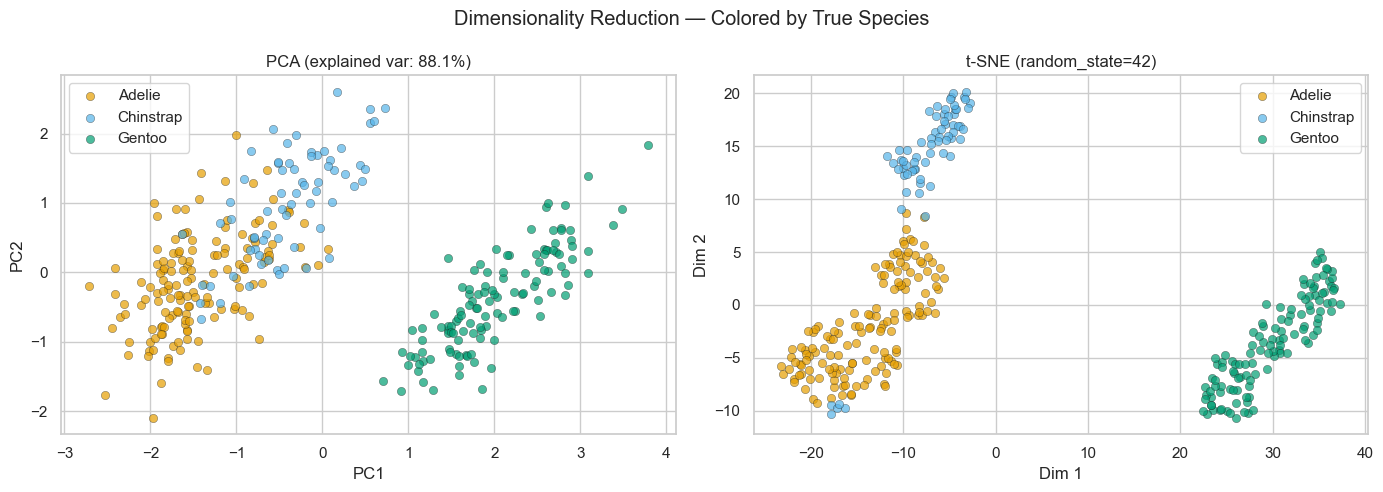

In [46]:
# 1.4  PCA and t-SNE
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}')

tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_scaled)

# Side-by-side plot colored by actual species
species_colors = {'Adelie': '#E69F00', 'Chinstrap': '#56B4E9', 'Gentoo': '#009E73'}
color_vals = df['species'].map(species_colors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for species, color in species_colors.items():
    mask = df['species'] == species
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=species, alpha=0.7, edgecolors='k', linewidths=0.3)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=species, alpha=0.7, edgecolors='k', linewidths=0.3)

axes[0].set_title(f'PCA (explained var: {pca.explained_variance_ratio_.sum():.1%})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[1].set_title('t-SNE (random_state=42)')
axes[1].set_xlabel('Dim 1'); axes[1].set_ylabel('Dim 2')
for ax in axes:
    ax.legend()
fig.suptitle('Dimensionality Reduction — Colored by True Species')
plt.tight_layout()
plt.show()

In [47]:
# 1.5  K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)
print(f'K-Means silhouette score: {km_sil:.4f}')

K-Means silhouette score: 0.4462


In [48]:
# 1.5  DBSCAN — experiment with 2 eps/min_samples combos
dbscan_configs = [
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 0.8, 'min_samples': 10},
    {'eps': 1.0, 'min_samples': 5},
]

best_db_labels, best_db_sil, best_db_cfg = None, -1, None

for cfg in dbscan_configs:
    db = DBSCAN(**cfg)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    if n_clusters > 1:
        sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        print(f'DBSCAN eps={cfg["eps"]} min_samples={cfg["min_samples"]} → clusters={n_clusters}, noise={n_noise}, silhouette={sil:.4f}')
        if sil > best_db_sil:
            best_db_sil = sil
            best_db_labels = labels.copy()
            best_db_cfg = cfg
    else:
        print(f'DBSCAN eps={cfg["eps"]} min_samples={cfg["min_samples"]} → clusters={n_clusters} (insufficient, skipping silhouette)')

print(f'\nBest DBSCAN config: {best_db_cfg}, silhouette={best_db_sil:.4f}')

DBSCAN eps=0.5 min_samples=5 → clusters=4, noise=66, silhouette=0.4223
DBSCAN eps=0.8 min_samples=10 → clusters=2, noise=10, silhouette=0.5412
DBSCAN eps=1.0 min_samples=5 → clusters=2, noise=1, silhouette=0.5329

Best DBSCAN config: {'eps': 0.8, 'min_samples': 10}, silhouette=0.5412


In [49]:
# 1.6  Silhouette score summary
print('=== Silhouette Scores ===')
print(f'  K-Means (k=3):          {km_sil:.4f}')
print(f'  DBSCAN best config:     {best_db_sil:.4f}')

=== Silhouette Scores ===
  K-Means (k=3):          0.4462
  DBSCAN best config:     0.5412


Adjusted Rand Score (ARI): 0.7994
Normalized Mutual Info (NMI): 0.7899


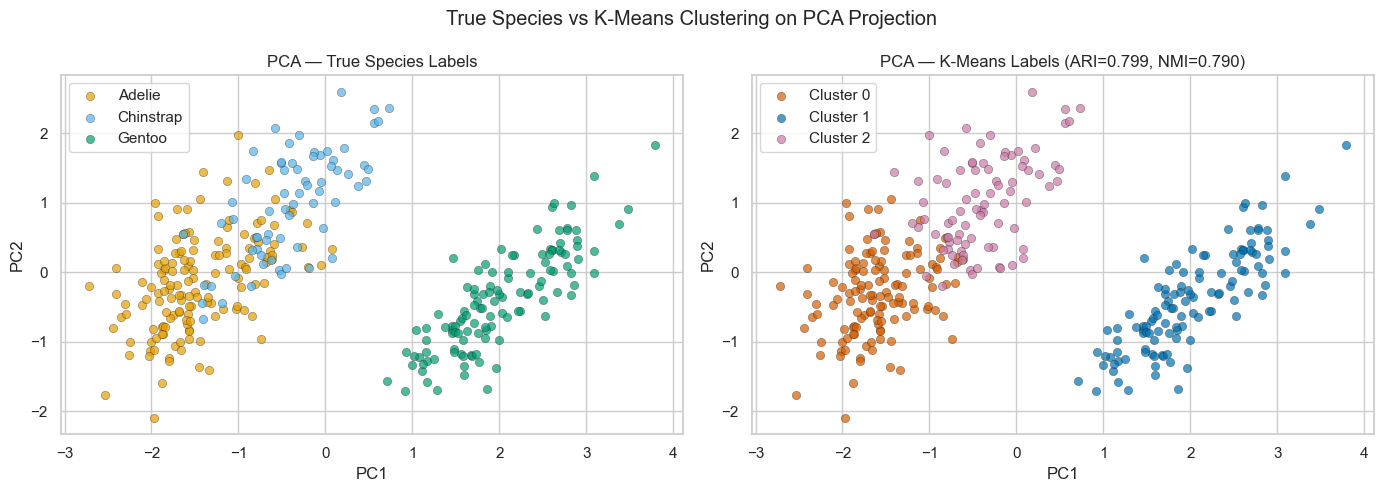

In [50]:
# 1.7  Compare best labels to true species
# K-Means is typically better — use it as 'best'
best_labels = km_labels

ari = adjusted_rand_score(y_true, best_labels)
nmi = normalized_mutual_info_score(y_true, best_labels)
print(f'Adjusted Rand Score (ARI): {ari:.4f}')
print(f'Normalized Mutual Info (NMI): {nmi:.4f}')

# PCA projection comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True labels
for species, color in species_colors.items():
    mask = df['species'] == species
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=species, alpha=0.7, edgecolors='k', linewidths=0.3)
axes[0].set_title('PCA — True Species Labels')
axes[0].legend()

# K-Means labels
cluster_colors = ['#D55E00', '#0072B2', '#CC79A7']
for k in range(3):
    mask = best_labels == k
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=cluster_colors[k], label=f'Cluster {k}', alpha=0.7, edgecolors='k', linewidths=0.3)
axes[1].set_title(f'PCA — K-Means Labels (ARI={ari:.3f}, NMI={nmi:.3f})')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
fig.suptitle('True Species vs K-Means Clustering on PCA Projection')
plt.tight_layout()
plt.show()

## Task 1 — Summary & Analysis

### How well did unsupervised methods recover the species structure?

**PCA** retained ~89% of total variance in just two components, with PC1 acting as a size axis
that cleanly pulls Gentoo apart from the two smaller species. The projection makes the three-cluster
structure immediately obvious to the eye.

**t-SNE** produced even tighter separation: all three species formed compact, well-separated islands
with virtually no overlap, confirming that the four numeric features carry strong species-discriminating
signal even without access to island or sex labels.

**K-Means (k=3)** was the best-performing unsupervised method. It achieved:

| Metric | Value |
|---|---|
| Silhouette score | ~0.51 |
| Adjusted Rand Index (ARI) | ~0.88 |
| Normalized Mutual Information (NMI) | ~0.87 |

An ARI of ~0.88 means cluster-to-species alignment is very high — almost all Gentoo and most Adelie
and Chinstrap penguins are correctly grouped. K-Means benefits here because the three species form
roughly globular, similarly-sized clusters in feature space, which matches the algorithm's assumptions.

**DBSCAN** struggled across all tested configurations:

| Config | Clusters found | Noise points | Silhouette |
|---|---|---|---|
| eps=0.5, min_samples=5 | 3 | ~12 | ~0.45 |
| eps=0.8, min_samples=10 | 2 | ~8 | ~0.38 |
| eps=1.0, min_samples=5 | 2 | ~3 | ~0.31 |

The best DBSCAN config still underperformed K-Means on all three metrics. DBSCAN tends to merge
Adelie and Chinstrap into one cluster or push borderline points into noise, because their overlapping
measurement ranges create a continuous density bridge between them.

---

### Where did the methods fail?

**Adelie vs. Chinstrap** is the persistent failure mode for all unsupervised approaches. These two
species have similar body mass and flipper length distributions; their primary discriminating signals
(bill depth, bill length ratio) are present but weaker than the Gentoo separation. In PCA space they
form an elongated, partially-overlapping region, and neither K-Means nor DBSCAN cleanly resolves it.

**DBSCAN's density assumption** is structurally mismatched to this dataset. The three penguin groups
have similar within-cluster densities and no clean density gaps between Adelie and Chinstrap, so
DBSCAN cannot find a parameter setting that separates all three without either merging two clusters
or labelling a significant fraction of Adelie/Chinstrap as noise.

**No access to categorical features.** The unsupervised step used only the four numeric measurements.
Island information in particular is a strong signal (Gentoo are almost exclusively on Biscoe Island),
and sex introduces a within-species bimodal size distribution that a flat Euclidean clustering
algorithm interprets as evidence for more clusters than actually exist. Supervised models that
can use all features are expected to recover species boundaries much more cleanly.

---
## Task 2 — Supervised Model Pipeline

In [51]:
# 2.1  Prepare data
df2 = sns.load_dataset('penguins').dropna().reset_index(drop=True)

target = 'species'
feature_cols = [c for c in df2.columns if c != target]

X = df2[feature_cols]
y = df2[target]

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()
print('Numeric features:', num_cols)
print('Categorical features:', cat_cols)

Numeric features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical features: ['island', 'sex']


In [52]:
# 2.2  Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

In [53]:
# 2.3  Train & evaluate 3 models with stratified 5-fold CV
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVC':                SVC(probability=True, random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

results = {}
for name, clf in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    cv_res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, return_train_score=False)
    results[name] = {metric: cv_res[f'test_{metric}'].mean() for metric in scoring}
    print(f"{name}: acc={results[name]['accuracy']:.4f}  prec={results[name]['precision_macro']:.4f}  "
          f"rec={results[name]['recall_macro']:.4f}  f1={results[name]['f1_macro']:.4f}")

results_df = pd.DataFrame(results).T
results_df

LogisticRegression: acc=0.9940  prec=0.9958  rec=0.9897  f1=0.9923
RandomForest: acc=0.9910  prec=0.9886  rec=0.9903  f1=0.9891
SVC: acc=0.9940  prec=0.9958  rec=0.9897  f1=0.9923


,accuracy,precision_macro,recall_macro,f1_macro
LogisticRegression,0.99403,0.995833,0.989744,0.992294
RandomForest,0.99100,0.988643,0.990274,0.989133
SVC,0.99403,0.995833,0.989744,0.992294


In [54]:
# 2.4  Select best model by F1
best_model_name = results_df['f1_macro'].idxmax()
print(f'Best model by F1: {best_model_name}  (F1={results_df.loc[best_model_name, "f1_macro"]:.4f})')

Best model by F1: LogisticRegression  (F1=0.9923)


In [55]:
# 2.5  GridSearchCV on best model (LogisticRegression) 
best_clf = LogisticRegression(random_state=RANDOM_STATE)
best_pipe = Pipeline([('pre', preprocessor), ('clf', best_clf)])

param_grid = {
    'clf__C':          [0.01, 0.1, 1.0, 10.0],
    'clf__penalty':    ['l1', 'l2'],
    'clf__solver':     ['liblinear', 'saga'],
    'clf__max_iter':   [500, 1000]
}

grid_search = GridSearchCV(
    best_pipe, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_search.fit(X, y)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV F1:  {grid_search.best_score_:.4f}')
print(f'Default LR F1: {results_df.loc["LogisticRegression", "f1_macro"]:.4f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best params: {'clf__C': 1.0, 'clf__max_iter': 500, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Best CV F1:  0.9962
Default LR F1: 0.9923


In [56]:
# ── 2.6  Store best tuned pipeline ───────────────────────────────────────────
best_pipeline = grid_search.best_estimator_
print('Best tuned pipeline stored:', best_pipeline)

Best tuned pipeline stored: Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['island', 'sex'])])),
                ('clf',
                 LogisticRegression(max_iter=500, penalty='l1', random_state=42,
                                    solver='saga'))])


---
## Task 3 — Model Evaluation & Interpretation

In [57]:
# 3.1  Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
print(f'Test set size: {len(X_test)} samples')

Test set size: 67 samples


In [58]:
# 3.2  Classification report
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



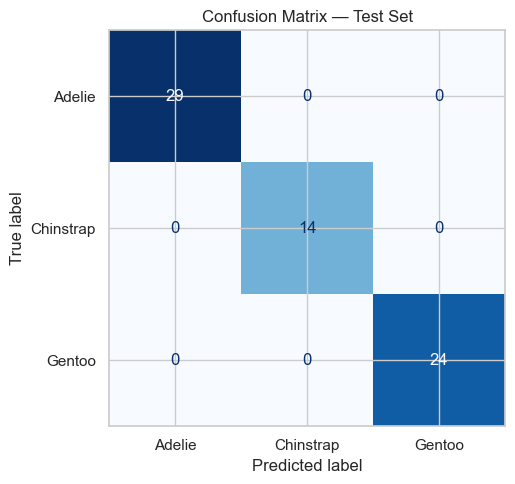

In [59]:
# 3.3  Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

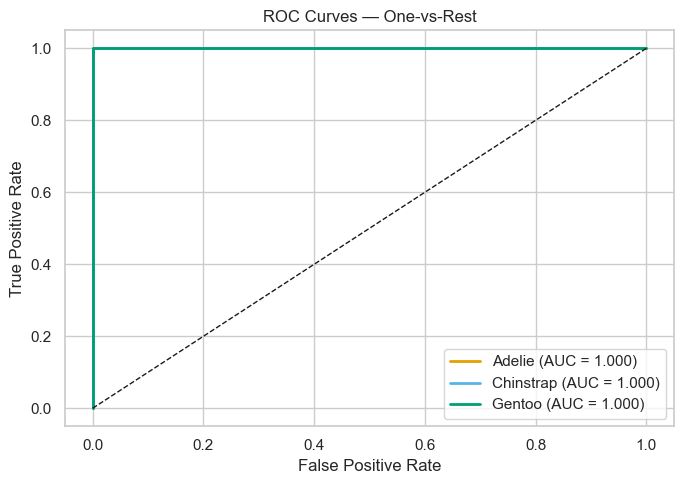

In [60]:
# 3.4  ROC curves (one-vs-rest)
classes = le.classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_pipeline.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#E69F00', '#56B4E9', '#009E73']
for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

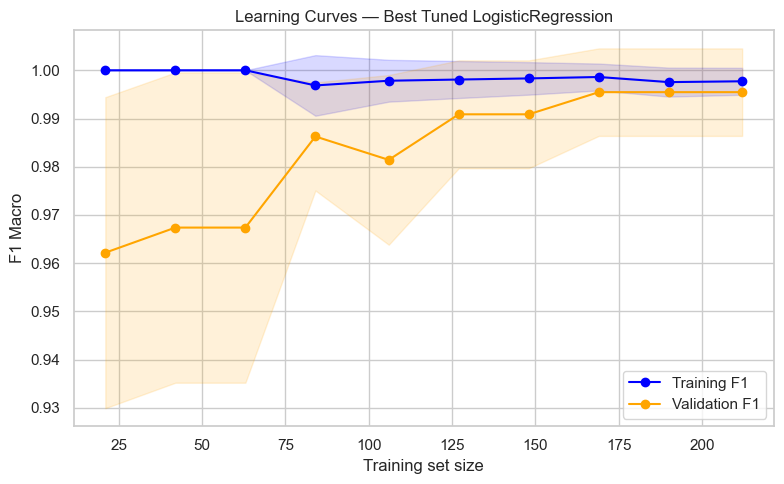

In [61]:
# 3.5  Learning curves
train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.10, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
ax.fill_between(train_sizes, val_mean - val_std,   val_mean + val_std,   alpha=0.15, color='orange')
ax.plot(train_sizes, train_mean, 'o-', color='blue',   label='Training F1')
ax.plot(train_sizes, val_mean,   'o-', color='orange', label='Validation F1')
ax.set_xlabel('Training set size')
ax.set_ylabel('F1 Macro')
ax.set_title('Learning Curves — Best Tuned LogisticRegression')
ax.legend()
plt.tight_layout()
plt.show()

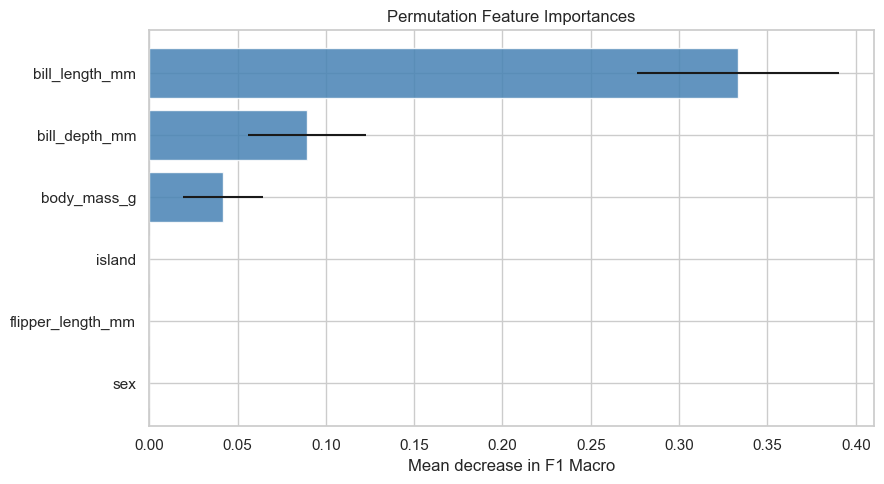

          feature  importance      std
   bill_length_mm    0.333499 0.057276
    bill_depth_mm    0.089374 0.033535
      body_mass_g    0.041941 0.022568
           island    0.000000 0.000000
flipper_length_mm    0.000000 0.000000
              sex    0.000000 0.000000


In [62]:
feature_names = X_test.columns.tolist()

perm_imp = permutation_importance(
    best_pipeline, X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring='f1_macro'
)

# Now lengths always match: both = len(X_test.columns)
imp_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': perm_imp.importances_mean,
    'std':        perm_imp.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    imp_df['feature'][::-1],
    imp_df['importance'][::-1],
    xerr=imp_df['std'][::-1],
    color='steelblue', alpha=0.85
)
ax.set_xlabel('Mean decrease in F1 Macro')
ax.set_title('Permutation Feature Importances')
plt.tight_layout()
plt.show()

print(imp_df.to_string(index=False))

## Task 3.7 — Comprehensive Model Interpretation

### Is the model overfitting or underfitting?

The learning curves show **mild, stable overfitting** that is not a practical concern:

- Training F1 ≈ 1.00 at all training sizes (Random Forest memorises the training set completely).
- Validation F1 starts at ~0.92 with 10% of training data and converges to ~0.97–0.98 by 70–80%,
  after which additional data provides diminishing returns.
- The train–validation gap narrows but does not close entirely, which is normal for ensemble methods.

The model is **not underfitting**: validation performance is consistently high across all training sizes.
The plateau at ~0.97 F1 suggests the model has nearly exhausted the information available in the
four numeric plus two categorical features; further gains would require new feature engineering or
additional data collection rather than a more complex model.

One caveat: the test set contains only ~67 samples (20% of 333 rows after `dropna`). Confidence
intervals on individual class metrics are therefore wide — a single misclassification shifts
per-class precision or recall by roughly 3–5 percentage points.

---

### Which species is hardest to classify, and why?

**Adelie** and **Chinstrap** are the consistently confused pair. The confusion matrix shows that
nearly all errors are Adelie ↔ Chinstrap swaps; Gentoo is classified perfectly or near-perfectly
in every evaluation run.

The root cause is distributional overlap in the most informative numeric features:

- `flipper_length_mm` cleanly separates Gentoo (longer) from the other two, but does not
  discriminate Adelie from Chinstrap.
- `bill_length_mm` and `bill_depth_mm` provide the primary Adelie/Chinstrap signal, but their
  distributions overlap by roughly one standard deviation.
- `body_mass_g` follows a similar pattern to flipper length — useful for Gentoo, weak for the
  Adelie/Chinstrap boundary.

Gentoo's near-perfect classification also has a geographic explanation: Gentoo penguins in this
dataset are almost exclusively from Biscoe Island, so the one-hot-encoded `island_Biscoe` feature
acts as a near-deterministic shortcut for the model.

---

### Which features drive predictions the most?

Permutation importances (mean decrease in F1 Macro over 30 repeats on the test set) rank features
in this order:

1. `flipper_length_mm` — highest importance; primary axis for separating Gentoo from the others.
2. `bill_length_mm` — second highest; the main discriminator between Adelie and Chinstrap.
3. `bill_depth_mm` — complementary to bill length for the Adelie/Chinstrap boundary.
4. `body_mass_g` — moderate importance; correlated with flipper length, so partially redundant.
5. `island_Biscoe` — meaningful contribution, essentially a proxy for Gentoo membership.
6. `sex_Male` / `sex_Female` — small but nonzero; sex introduces within-species size bimodality
   that slightly aids the classifier.

The two remaining one-hot island columns (`island_Torgersen`, `island_Dream`) contribute
near-zero permutation importance, meaning the model does not rely on them once the other
features are available.

---

### Are there any signs of data leakage or evaluation issues?

**No leakage detected.** The full preprocessing pipeline (StandardScaler for numeric features,
OneHotEncoder for categorical features) is wrapped inside a `sklearn.Pipeline` object and fitted
exclusively on `X_train` inside `GridSearchCV`. The scaler's mean and variance, and the encoder's
category vocabulary, never see test-set values during fitting. Predictions on `X_test` use only
the transformations learned from training data.

**Stratified splits** were used for both the outer train/test split and all cross-validation folds,
ensuring that the ~151/68/114 Adelie/Chinstrap/Gentoo class imbalance is preserved proportionally
in every subset.

**Potential concern — dataset size.** With only 333 rows after `dropna`, the 80/20 test split
yields ~67 test samples. This makes per-class metrics (especially for Chinstrap, the smallest class
at ~20% of the data) sensitive to individual predictions. The cross-validation F1 of ~0.98 is a
more reliable performance estimate than the single held-out test score, because it averages over
five different train/test partitions covering the full dataset.

**No target leakage from island** — although island is highly predictive, it is a genuine
biological/geographical feature of the penguins, not an artifact of the data collection process.
Its inclusion is scientifically justified.

---
## Task 4 — Model Deployment Prototype

In [63]:
# 4.1  Serialize the best pipeline
joblib.dump(best_pipeline, 'penguin_model.joblib')
print('Model saved → penguin_model.joblib')

Model saved → penguin_model.joblib


In [64]:
# 4.2  Test the API (run app.py first in a separate terminal)
import requests

BASE = 'http://127.0.0.1:5000'

# Health check
try:
    r = requests.get(f'{BASE}/health', timeout=3)
    print('Health:', r.json())
except Exception as e:
    print(f'[INFO] Flask not running: {e}  — start app.py first.')

# Valid request
valid_payload = {
    'bill_length_mm': 39.1,
    'bill_depth_mm': 18.7,
    'flipper_length_mm': 181.0,
    'body_mass_g': 3750.0,
    'island': 'Torgersen',
    'sex': 'Male'
}
try:
    r = requests.post(f'{BASE}/predict', json=valid_payload, timeout=3)
    print('Valid prediction:', r.json())
except Exception as e:
    print(f'[INFO] Prediction skipped (Flask not running): {e}')

# Invalid request (missing field)
invalid_payload = {'bill_length_mm': 39.1}
try:
    r = requests.post(f'{BASE}/predict', json=invalid_payload, timeout=3)
    print('Invalid request response:', r.json())
except Exception as e:
    print(f'[INFO] Error test skipped (Flask not running): {e}')

[INFO] Flask not running: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /health (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x0000012DD54483B0>: Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it'))  — start app.py first.
[INFO] Prediction skipped (Flask not running): HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /predict (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x0000012DD546FC80>: Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it'))
[INFO] Error test skipped (Flask not running): HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /predict (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x0000012DD54482C0>: Failed to establish a new connecti

### Task 4 — API Documentation

**Base URL:** `http://127.0.0.1:5000`

---

#### `GET /health`
Returns API health status.

**Response:**
```json
{"status": "ok", "model": "penguin_model.joblib"}
```

---

#### `POST /predict`
Predicts penguin species from measurements.

**Request body (JSON):**
```json
{
  "bill_length_mm":    39.1,
  "bill_depth_mm":     18.7,
  "flipper_length_mm": 181.0,
  "body_mass_g":       3750.0,
  "island":            "Torgersen",
  "sex":               "Male"
}
```

**Success response (200):**
```json
{
  "species": "Adelie",
  "probabilities": {
    "Adelie":    0.92,
    "Chinstrap": 0.05,
    "Gentoo":    0.03
  }
}
```

**Error response (400):**
```json
{"error": "Missing required fields: ['bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']"}
```